#### 13.8 区域卷积神经网络（R-CNN）系列
- 区域卷积神经网络（Region-Based CNN/Regions with CNN Features）：将深度模型应用于目标检测，包括：
    - Fast R-CNN
    - Faster R-CNN
    - Mask R-CNN
##### 13.8.1 R-CNN
在输入图像中提取若干个提议区域，标注其类别和边界框，使用卷积神经网络对每个提议区域进行前向传播提取特征：
- 对输入图像使用选择性搜索来选取多个高质量提议区域，具有不同尺度、形状，被标注类别和真实边界框；
- 选择一个与训练的卷积神经网络，并将其在输出层之前阶段，每个提议区域变形为网络所需的输入尺寸，通过前向传播提取特征；
- 将每个提议区域的特征联通其标注的类别作为一个样本，训练多个支持向量机对目标分类，其中每个支持向量机用来判断样本是否属于某一个类别；
- 将每个提议区域的特征连同其标注的边界框作为一个样本，训练线性回归模型来预测真实边界框。

缺点：需要上千次提取和前向传播，速度慢。

##### 13.8.2 Fast R-CNN
对于R-CNN的每个提议区域，卷积神经网络的前向传播是独立的，没有共享计算，且对于重叠区域会导致重复计算。Fast R-CNN的引入，仅在整张图象上执行卷积神经网络的前向传播：
- 输入整张图像，卷积神经网络的输出形状为$1\times c\times h_1\times w_1$；
- 假设选择性搜索生成了$n$个提议区域，，在卷积神经网络的输出上分别标出了兴趣区域，进一步提取出形状相同的特征，引入兴趣区域汇聚层（RoI Pooling），即将卷积神经网络的输出和提议区域作为输入，输出连接后的各个提议区域提取的特征，形状为$(n\times c\times h_2\times w_2)$；
- 通过全连接层将输出形状转换为$n\times d$；
- 预测$n$个提议区域中每个区域的类别和边界框，即将全连接层的输出分别转换为形状为$n\times q$（$q$为类别数量）的输出和形状为$n\times4$的输出，使用softmax回归。

In [1]:
import torch
import torchvision

X = torch.arange(16.).reshape(1, 1, 4, 4)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

假设输入图像形状为$40\times40$，生成两个提议区域，由`rois`表示，五个元素分别为：区域目标类别、左上角和右下角的坐标。`X`的高宽均为输入图像的$\frac{1}{10}$，按`spatial_scale`乘0.1，标出两个兴趣区域，最后提取相同形状$2\times2$的特征。

In [3]:
rois = torch.Tensor([[0, 0, 0, 20, 20], [0, 0, 10, 30, 30]])
torchvision.ops.roi_pool(X, rois, output_size=(2, 2), spatial_scale=0.1)

tensor([[[[ 5.,  6.],
          [ 9., 10.]]],


        [[[ 9., 11.],
          [13., 15.]]]])

##### 13.8.3 Faster R-CNN
将选择性搜索改为区域提议网络，减少提议区域生成数量，保持目标检测的精确度：
- 使用填充为1的3×3卷积层转换卷积神经网络的输出，即输出通道数为$c$，使特征图每个单元得到长度为$c$的新特征；
- 以特征图的每个像素为中心，生成多个不同大小的宽高比的描框来标注；
- 使用描框中心单元长度为$c$的特征，分别预测该描框的二元类别，即目标或背景；
- 使用非极大值抑制，移除相似结果，最终输出兴趣区域汇聚层所需的提议区域。

##### 13.8.4 Mask R-CNN
如果在训练集中标注了每个目标在图像上的像素级位置，则Mask R-CNN能够有效地利用这些相近的标注信息进一步提升目标检测的精准性。它将兴趣区域汇聚层替换为兴趣区域对齐层，使用双线性插值（Bilinear Interpolation）来保留特征图上的空间信息，适用于像素级预测。

---

#### 13.9 语义分割和数据集
- 语义分割（Semantic Segmentation）：将图像分割成属于不同语义类别的区域，可以像素级地识别图像中的内容。
##### 13.9.1 图像分割和实例分析
区分：
- 图像分割（Image Segmentaion）：将图像划分为若干组成区域。
- 实例分割（Instance Segmentation）/同时检测并分割（Simultaneous Detection and Segmentation）：研究识别图像中的各个目标实例的像素级区域，不仅需要区分语义，还要区分目标实例。

##### 13.9.2 Pascal VOC2012语义分割数据集

In [8]:
import os
import torch
import torchvision
from torch import nn
import tarfile
from d2l import torch as d2l

In [18]:
voc_path = "/Users/zhangweixuan_private/Desktop/Code/DeepLearning_PyTorch/data/VOCtrainval_11-MAY-2012.tar"
extract_dir = "/Users/zhangweixuan_private/Desktop/Code/DeepLearning_PyTorch/data"
with tarfile.open(voc_path, 'r') as tar:
    tar.extractall(path=extract_dir)
voc_dir = os.path.join(extract_dir, "VOCdevkit", "VOC2012")
train_features, train_labels = read_voc_images(voc_dir, True)

In [19]:
#@save
def read_voc_images(voc_dir, is_train=True):
    """读取所有VOC图像并标注"""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

train_features, train_labels = read_voc_images(voc_dir, True)

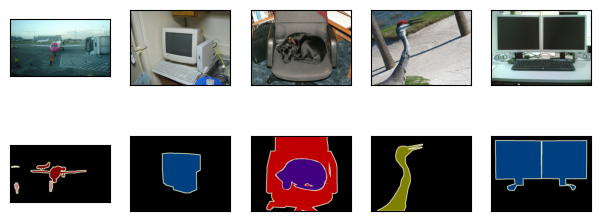

In [20]:
n = 5
imgs = train_features[0:n] + train_labels[0:n]
imgs = [img.permute(1,2,0) for img in imgs]
d2l.show_images(imgs, 2, n);

In [21]:
#@save
VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

#@save
VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

定义`voc_colormap2label()`构建上述RGB颜色值到类别索引的映射；定义`voc_label_indices()`将RGB值映射到Pascal VOC2012数据集的类别索引。

In [22]:
#@save
def voc_colormap2label():
    """构建从RGB到VOC类别索引的映射"""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

#@save
def voc_label_indices(colormap, colormap2label):
    """将VOC标签中的RGB值映射到它们的类别索引"""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

In [23]:
y = voc_label_indices(train_labels[0], voc_colormap2label())
y[105:115, 130:140], VOC_CLASSES[1]

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]),
 'aeroplane')

1. 数据预处理

在语义分割中将预测的像素类被映射回原始尺寸的输入图像，会降低精确性。为避免该情况，采用固定尺寸裁剪取代缩放，即使用图像增广的随即裁剪，裁剪输入图像的标签和相同区域。

In [30]:
#@save
def voc_rand_crop(feature, label, height, width):
    """随机裁剪特征和标签图像"""
    rect = torchvision.transforms.RandomCrop.get_params(feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

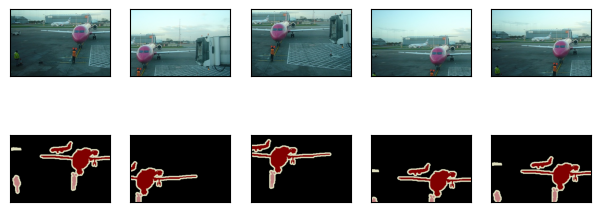

In [31]:
imgs = []
for _ in range(n):
    imgs += voc_rand_crop(train_features[0], train_labels[0], 200, 300)
imgs = [img.permute(1,2,0) for img in imgs]
d2l.show_images(imgs[::2] + imgs[1::2], 2, n)

2. 自定义语义分割数据集类

通过实现`__getitem__()`，任意访问数据集中索引为`idx`的输入图像及其每个像素的类别索引，自定义一个数据集类`VOCSegDataset`；通过`filter()`移除尺寸小于随即裁剪指定输出尺寸的图像；通过`normalize_image()`对输入图像的RGB三个通道的值进行标准化。

In [32]:
#@save
class VOCSegDataset(torch.utils.data.Dataset):
    """一个用于加载VOC数据集的自定义数据集"""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

3. 读取数据集

通过`VOCSegDataset`类来分别创建训练集和测试集的实例，设置裁剪输出图像大小为(320,480)。

In [34]:
crop_size = (320, 480)
voc_train = VOCSegDataset(True, crop_size, voc_dir)
voc_test = VOCSegDataset(False, crop_size, voc_dir)

read 1114 examples
read 1078 examples


定义训练集迭代器。

In [ ]:
batch_size = 64
# macOS + Python + Jupyter无法开启多进程，num_workers应该为0
train_iter = torch.utils.data.DataLoader(voc_train, batch_size, shuffle=True, drop_last=True, num_workers=0)
for X, Y in train_iter:
    print(X.shape)
    print(Y.shape)
    break

torch.Size([64, 3, 320, 480])
torch.Size([64, 320, 480])


4. 整合所有组件

定义`load_data_voc()`加载并读取Pascal VOC2012语义分割数据集，返回训练集和测试集的数据迭代器。

In [ ]:
#@save
def load_data_voc(batch_size, crop_size):
    """加载VOC语义分割数据集"""
    voc_dir = d2l.download_extract('voc2012', os.path.join('VOCdevkit', 'VOC2012'))
    num_workers = d2l.get_dataloader_workers()
    train_iter = torch.utils.data.DataLoader(VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

#### 13.10 转置卷积
- 转置卷积（Transposed Convolution）：用于逆转下采样导致的空间维度减小。
##### 13.10.1 基本操作
设输入张量$n_h\times n_w$和卷积核$k_h\times k_w$，以步幅为1滑动卷积核窗口，每行$n_w$次，每列$n_h$次，产生$n_hn_w$个中间结果$(n_h+k_h-1)\times(n_w+k_w-1)$，初始为0。

定义`trans_conv()`实现转置运卷积。

In [1]:
def trans_conv(X, k):
    h, w = K.shape
    Y = torch.zeros((X.shape[0] + h - 1, X.shape[1] + w - 1))
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Y[i:i+h, j:j+w] += X[i, j] * k
    return Y

In [ ]:
# X，K必须是浮点数
X = torch.tensor([[0., 1.], [2., 3.]])
K = torch.tensor([[0., 1.], [2., 3.]])
trans_conv(X, K)

tensor([[ 0.,  0.,  1.],
        [ 0.,  4.,  6.],
        [ 4., 12.,  9.]])

In [14]:
# 使用高级API
X, K = X.reshape(1, 1, 2, 2), K.reshape(1, 1, 2, 2)
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[ 0.,  0.,  1.],
          [ 0.,  4.,  6.],
          [ 4., 12.,  9.]]]], grad_fn=<ConvolutionBackward0>)

##### 13.10.2 填充、步幅和多通道
转置卷积中，填充用于输出而非输入。

In [15]:
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, padding=1, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[4.]]]], grad_fn=<ConvolutionBackward0>)

##### 13.10.3 与矩阵变换的联系

In [17]:
X = torch.arange(9.).reshape(3, 3)
K = torch.tensor([[1., 2.], [3., 4.]])

In [18]:
# 使用corr2d计算卷积输出
Y = d2l.corr2d(X, K)
Y

tensor([[27., 37.],
        [57., 67.]])

In [19]:
# 将卷积核K写为包含大量0的稀疏权重矩阵W，形状为(4,9)
def kernel2matrix(K):
    k, W = torch.zeros(5), torch.zeros((4, 9))
    k[:2], k[3:5] = K[0, :], K[1, :]
    W[0, :5], W[1, 1:6], W[2, 3:8], W[3, 4:] = k, k, k, k
    return W

W = kernel2matrix(K)
W

tensor([[1., 2., 0., 3., 4., 0., 0., 0., 0.],
        [0., 1., 2., 0., 3., 4., 0., 0., 0.],
        [0., 0., 0., 1., 2., 0., 3., 4., 0.],
        [0., 0., 0., 0., 1., 2., 0., 3., 4.]])

In [21]:
Y == torch.matmul(W, X.reshape(-1)).reshape(2, 2)

tensor([[True, True],
        [True, True]])

结论，给定输入向量$\mathbf{x}$和权重矩阵$\mathbf{W}$，卷积的前向传播函数可以通过输入与权重矩阵相乘输出向量$\mathbf{y}=\mathbf{Wx}$实现。根据反向传播链式法则$\nabla_{\mathbf{x}}\mathbf{y}=\mathbf{W}^T$，卷积反向传播函数可以通过输入与权重转置$\mathbf{W}^T$相乘实现，因此转置卷积层能够通过分别将输入向量乘以$\mathbf{W}$和$\mathbf{w}^T$来实现交换卷积层的前向传播函数和反向传播函数。